In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.9.1'

In [3]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [5]:
train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [6]:
def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None):
    """
    Plots training data, test data and compares predictions.
    """

    plt.figure(figsize=(5, 5))

    plt.scatter(train_data, train_labels, c='b', s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14})

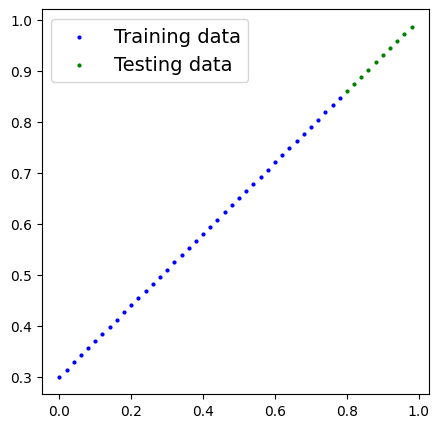

In [7]:
plot_predictions()

In [ ]:
class LinearRegressionModel(nn.Module): # torch.nn.Module is a base class for all neural networks. Requires forward() method.
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(
            torch.randn(1,                  # Start with random weights (they get adjusted as the model learns)
                        dtype=torch.float), # Pytorch likes f32
            requires_grad=True
        )

        # requires_grad=True calculates gradients automatically, often referred to as autograd
        # Using requires_grad=True makes parameter update with gradient descent.

        self.bias = nn.Parameter(
            torch.randn(1, 
                        dtype=torch.float),
            requires_grad=True # This tracks gradients of this specific parameter for use with torch.autograd
        )

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias # This is linear regression formula


In [24]:
torch.randn(1, dtype=torch.float), torch.randn(1, dtype=torch.float)

(tensor([0.2345]), tensor([0.2303]))

In [25]:
torch.manual_seed(42) # Set manual seed since nn.Parameters are randomly initialized

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [26]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [28]:
with torch.inference_mode():
    y_preds = model_0(X_test)

print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


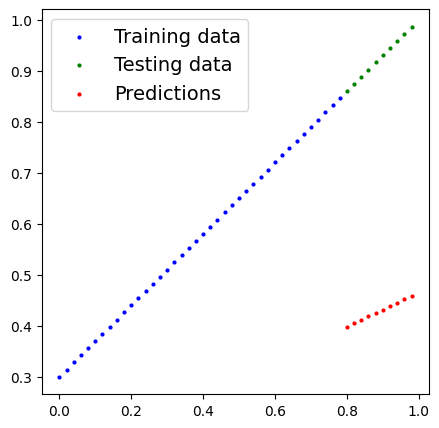

In [29]:
plot_predictions(predictions=y_preds)

In [ ]:
y_test - y_preds
# This predictions are really bad. We need a loss function and optimizer.

# Loss Function - Measures how bad the model is. Plenty of loss functions built-in in torch.nn
# Optimizer     - Tells your model how to update its internal parameters to best lower the loss. Various functions in torch.optim

# In case of regression models we often use MAE (Mean Absolute Error) - torch.nn.L1Loss(). Binary cross entropy for binary classification problems - torch.nn.BCELoss()
# Stohastic gradient descent - torch.optim.SGD(). Adam optimizer - torch.optim.Adam()

# SGD requires learning rate. It's set by an engineer thus it's referred to as a hyper parameter.

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

In [ ]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer 
optimizer = torch.optim.SGD(
    params=model_0.parameters(), # parameters of target model to optimize
    lr=0.01                      # learning rate (how much the optimizer should change parameters at each step) 
)

# Training and Testing loop

# Training
+ Forward pass
    Go through training data once performing its forward() function calculations - model(x_train)
+ Calculate the loss
    The model's outputs are compared to the ground truth and evaluated to se how wrong they are - loss = loss_fn(y_pred, y_train)
+ Zero gradients optimizer.zero_grad()
    The optimizer gradients are set to zero so they can be recalculated for the specific trainging step
+ Perform backpropagation on the loss
    Computes the gradient of the loss with respect for every model parameter to be updated (each parameter with requires_grad=True). This is known as backpropagation, hence "backwards". - loss.backwards()
+ Update the optimizer (gradient descent) - optimizer.step()

# Testing
+ Forward pass
    The model goes through all of the testing data once, performing its forward() function calculations.
    

In [ ]:
torch.manual_seed(42)

epochs = 200

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on training data using the forward() method inside
    y_pred = model_0(X_train)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Set oprimizers gradients to zero (they accumulate by default) so they
    #    can be recalculated at each step.
    optimizer.zero_grad()

    # 4. Loss backwards, performs backpropagation on the loss.
    #    Computes the gradient with respect for every model parameter to be updated.
    #    Known as backpropagation.
    loss.backward()

    # 5. Progress the optimizer. Upgrades parameters with requires_grad=True with respect
    #    to the loss gradients in order to improve them.
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
        # 1. Forward pass on test data
        test_pred = model_0(X_test)

        # 2. Calculate loss on test data
        test_loss = loss_fn(test_pred, y_test.type(torch.float))

        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss}")

Epoch: 0 | MAE Train Loss: 0.31288135051727295 | MAE Test Loss: 0.48106518387794495
Epoch: 10 | MAE Train Loss: 0.1976713389158249 | MAE Test Loss: 0.3463551998138428
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.2172965705394745
Epoch: 30 | MAE Train Loss: 0.053148530423641205 | MAE Test Loss: 0.14464019238948822
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953748226166
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633813381195
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937722325325
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484
Epoch: 90 | MAE Train Loss: 0.027887403964996338 | MAE Test Loss: 0.06473556160926819
Epoch: 100 | MAE Train Loss: 0.024458955973386765 | MAE Test Loss: 0.056463055312633514
Epoch: 110 | MAE Train Loss: 0.021020209416747093 | MAE Test Loss

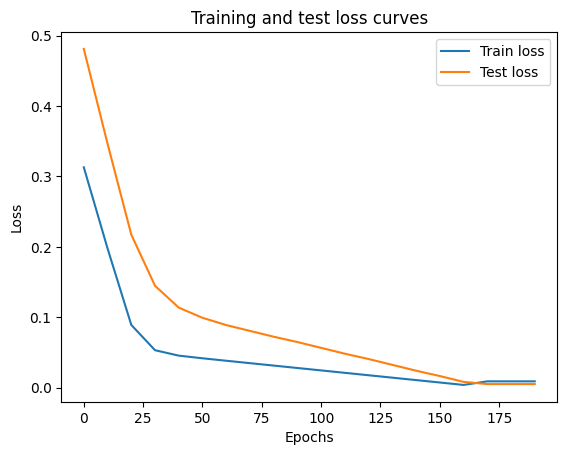

In [17]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [18]:
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.6990]), 'bias': tensor([0.3093])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


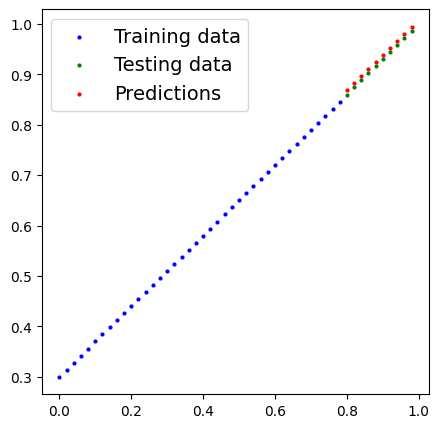

In [19]:
model_0.eval()

with torch.inference_mode():
    y_preds = model_0(X_test)

plot_predictions(predictions=y_preds)

In [20]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH) # only saving the state_dict() only saves the models learned parameters.

Saving model to: models/01_pytorch_workflow_model_0.pth


In [21]:
# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegressionModel()

# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [22]:
# 1. Put the loaded model into evaluation mode
loaded_model_0.eval()

with torch.inference_mode():
    # 2. Use the inference mode context manager to make predictions
    loaded_model_preds = loaded_model_0(X_test) # perform a forward pass on the test data with the loaded model

In [23]:
# Compare previous model predictions with loaded model predictions (THEY ARE THE SAME!!)
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])